# Restauração de Imagens (Inpainting) com Stable Diffusion

Este notebook implementa um pipeline de Inpainting utilizando o modelo `runwayml/stable-diffusion-inpainting`.
O objetivo é reconstruir áreas ocluídas de imagens do dataset Set14, avaliando a capacidade do modelo de gerar conteúdo coerente contextual e estruturalmente.

**Configuração:**
* **Hardware:** NVIDIA RTX 5070 (Float32 Precision)
* **Dataset:** Set14 (Amostras de Alta Resolução)
* **Tarefa:** Reconstrução central (Center Inpainting)

---


## 1. Configuração do Ambiente e Dependências
Verificação de hardware, carregamento de bibliotecas e definição de caminhos.

In [10]:
import torch
import numpy as np
import os
import warnings
from pathlib import Path
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from diffusers import StableDiffusionInpaintPipeline

# Configuração de logs
warnings.filterwarnings("ignore")

print("--- Verificação de Sistema ---")

# 1. Verificar GPU e definir precisão
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32 # Float32 mandatório para estabilidade do VAE na série RTX 40/50

if device == "cuda":
    print(f"GPU Detectada: {torch.cuda.get_device_name(0)}")
    print(f"VRAM Total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("Aviso: GPU não detectada. Execução em CPU será lenta.")

# 2. Definir Caminhos
ROOT_DIR = Path("./Set14").resolve()
OUTPUT_DIR = Path("./results_inpainting").resolve()
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Diretório do Dataset: {ROOT_DIR}")
print(f"Diretório de Saída: {OUTPUT_DIR}")


--- Verificação de Sistema ---
GPU Detectada: NVIDIA GeForce RTX 5070
VRAM Total: 12.82 GB
Diretório do Dataset: /mnt/c/Users/Pichau/Documents/Trabalhos Faculdade/MC949_Visao_Computacional/Trabalho 4/Set14
Diretório de Saída: /mnt/c/Users/Pichau/Documents/Trabalhos Faculdade/MC949_Visao_Computacional/Trabalho 4/results_inpainting


## 2. Inicialização do Modelo
Carregamento do pipeline `StableDiffusionInpaintPipeline` com otimizações de memória e fixação de precisão.

In [11]:
model_id = "runwayml/stable-diffusion-inpainting"

print(f"Carregando modelo: {model_id}...")

try:
    pipe = StableDiffusionInpaintPipeline.from_pretrained(
        model_id,
        torch_dtype=dtype,
        safety_checker=None # Desabilitado para economia de recursos e foco em restauração pura
    )
    pipe = pipe.to(device)

    # Fix Crítico: Forçar float32 nos componentes do VAE para evitar NaNs (imagens pretas)
    pipe.vae = pipe.vae.float()
    pipe.unet = pipe.unet.float()
    pipe.text_encoder = pipe.text_encoder.float()

    # Otimização de Atenção (Slicing)
    pipe.enable_attention_slicing()
    
    print("Modelo carregado e otimizado com sucesso.")

except Exception as e:
    print(f"Erro fatal ao carregar o modelo: {e}")
    raise e


Carregando modelo: runwayml/stable-diffusion-inpainting...


Loading pipeline components...:  33%|███▎      | 2/6 [00:01<00:03,  1.16it/s]An error occurred while trying to fetch /home/lucas/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/lucas/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline components...:  83%|████████▎ | 5/6 [00:02<00:00,  3.04it/s]An error occurred while trying to fetch /home/lucas/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/lucas/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb

Modelo carregado e otimizado com sucesso.


## 3. Preparação de Dados e Máscara
Seleção da imagem de entrada e geração automática da máscara de oclusão.

In [12]:
def load_and_process_image(root_dir, target_size=512):
    """Carrega a primeira imagem HR disponível e a ajusta para 512x512."""
    img_dir = root_dir / "image_SRF_2"
    images = sorted(img_dir.glob("*_HR.png"))
    
    if not images:
        raise FileNotFoundError(f"Nenhuma imagem HR encontrada em {img_dir}")
    
    img_path = images[0] # Seleciona a primeira imagem
    print(f"Imagem selecionada: {img_path.name}")
    
    img = Image.open(img_path).convert("RGB")
    
    # Central Crop/Resize para 512x512
    width, height = img.size
    if width < target_size or height < target_size:
        # Upscale com Lanczos se for menor
        ratio = max(target_size/width, target_size/height)
        new_size = (int(width*ratio), int(height*ratio))
        img = img.resize(new_size, Image.LANCZOS)
        
    # Crop central
    left = (img.width - target_size)/2
    top = (img.height - target_size)/2
    right = (img.width + target_size)/2
    bottom = (img.height + target_size)/2
    img = img.crop((left, top, right, bottom))
    
    return img, img_path.stem

def create_mask(image, ratio=0.35):
    """Cria uma máscara de inpainting quadrada centralizada."""
    w, h = image.size
    mask = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(mask)
    
    # Definir área do buraco
    hole_w, hole_h = int(w * ratio), int(h * ratio)
    x0 = (w - hole_w) // 2
    y0 = (h - hole_h) // 2
    x1 = x0 + hole_w
    y1 = y0 + hole_h
    
    draw.rectangle([x0, y0, x1, y1], fill=255)
    return mask, (x0, y0, x1, y1)

# Execução
source_image, img_name = load_and_process_image(ROOT_DIR)
mask_image, bbox = create_mask(source_image, ratio=0.35)

# Visualização prévia do input
preview = source_image.copy()
preview_draw = ImageDraw.Draw(preview)
preview_draw.rectangle(bbox, fill="gray")

print(f"Input preparado. Dimensões: {source_image.size}")


Imagem selecionada: img_001_SRF_2_HR.png
Input preparado. Dimensões: (512, 512)


## 4. Definição de Parâmetros (Prompt Engineering)
Nesta etapa definimos os comandos textuais que guiarão a reconstrução. O prompt deve descrever o conteúdo esperado ou o estilo geral da imagem para auxiliar o modelo.

In [13]:
# --- Parâmetros de Inferência ---

# Prompt Positivo: O que queremos ver/manter
prompt = "high quality, realistic, seamless texture, 4k, detailed"

# Prompt Negativo: O que queremos evitar
negative_prompt = "blur, artifacts, distortion, low resolution, text, watermark"

# Configurações do Modelo
num_inference_steps = 50  # Equilíbrio entre qualidade e velocidade
guidance_scale = 7.5      # Adesão ao prompt

print(f"📝 Prompt Atual: '{prompt}'")
print(f"🚫 Negative Prompt: '{negative_prompt}'")
print(f"⚙️  Steps: {num_inference_steps} | CFG Scale: {guidance_scale}")


📝 Prompt Atual: 'high quality, realistic, seamless texture, 4k, detailed'
🚫 Negative Prompt: 'blur, artifacts, distortion, low resolution, text, watermark'
⚙️  Steps: 50 | CFG Scale: 7.5


## 5. Execução do Inpainting
Processamento da imagem através do modelo de difusão.

In [14]:
print("Iniciando inferência...")

with torch.no_grad():
    result = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=source_image,
        mask_image=mask_image,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale
    )

output_image = result.images[0]

# Verificação de Integridade (Detecção de Black Image)
if np.array(output_image).max() == 0:
    print("⚠️ ALERTA: A imagem gerada está preta (falha numérica).")
else:
    print("✅ Inferência concluída com sucesso.")


Iniciando inferência...


100%|██████████| 50/50 [00:07<00:00,  6.90it/s]


✅ Inferência concluída com sucesso.


## 6. Análise de Resultados
Comparação visual entre a imagem original, a área mascarada e o resultado reconstruído.

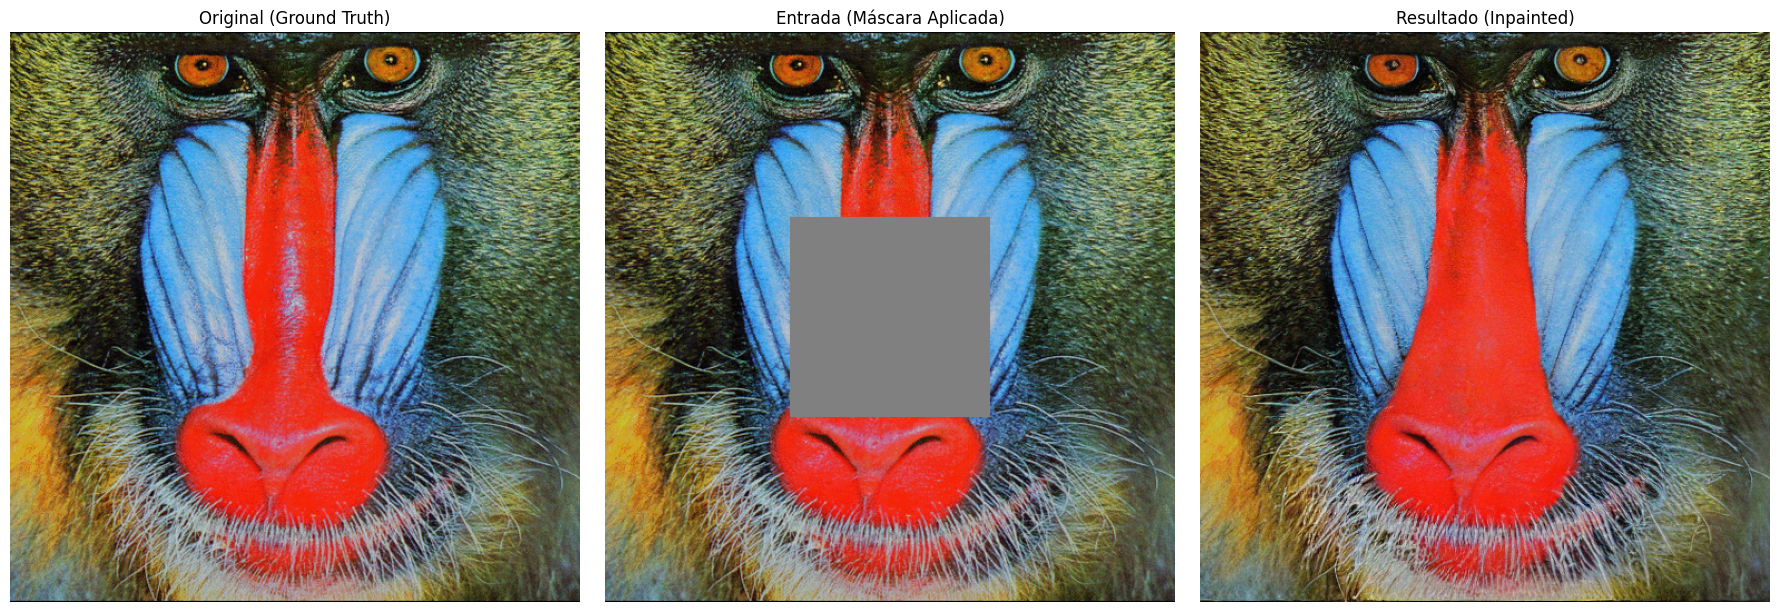

Resultado salvo em: /mnt/c/Users/Pichau/Documents/Trabalhos Faculdade/MC949_Visao_Computacional/Trabalho 4/results_inpainting


In [15]:
def show_comparison(original, masked, result):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(original)
    axes[0].set_title("Original (Ground Truth)")
    axes[0].axis("off")
    
    axes[1].imshow(masked)
    axes[1].set_title("Entrada (Máscara Aplicada)")
    axes[1].axis("off")
    
    axes[2].imshow(result)
    axes[2].set_title("Resultado (Inpainted)")
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.show()

show_comparison(source_image, preview, output_image)

# Salvar resultado principal
output_image.save(OUTPUT_DIR / f"{img_name}_result_main.png")
print(f"Resultado salvo em: {OUTPUT_DIR}")


## 7. Experimento: Variação de Prompts
Estudo ablativo para verificar como diferentes descrições textuais influenciam a reconstrução da área removida.

Executando teste com 3 variações de prompt...

Testando prompt: ''


100%|██████████| 30/30 [00:04<00:00,  7.01it/s]


Testando prompt: 'seamless texture matching original background'


100%|██████████| 30/30 [00:04<00:00,  6.85it/s]


Testando prompt: 'a red futuristic sphere'


100%|██████████| 30/30 [00:04<00:00,  7.31it/s]


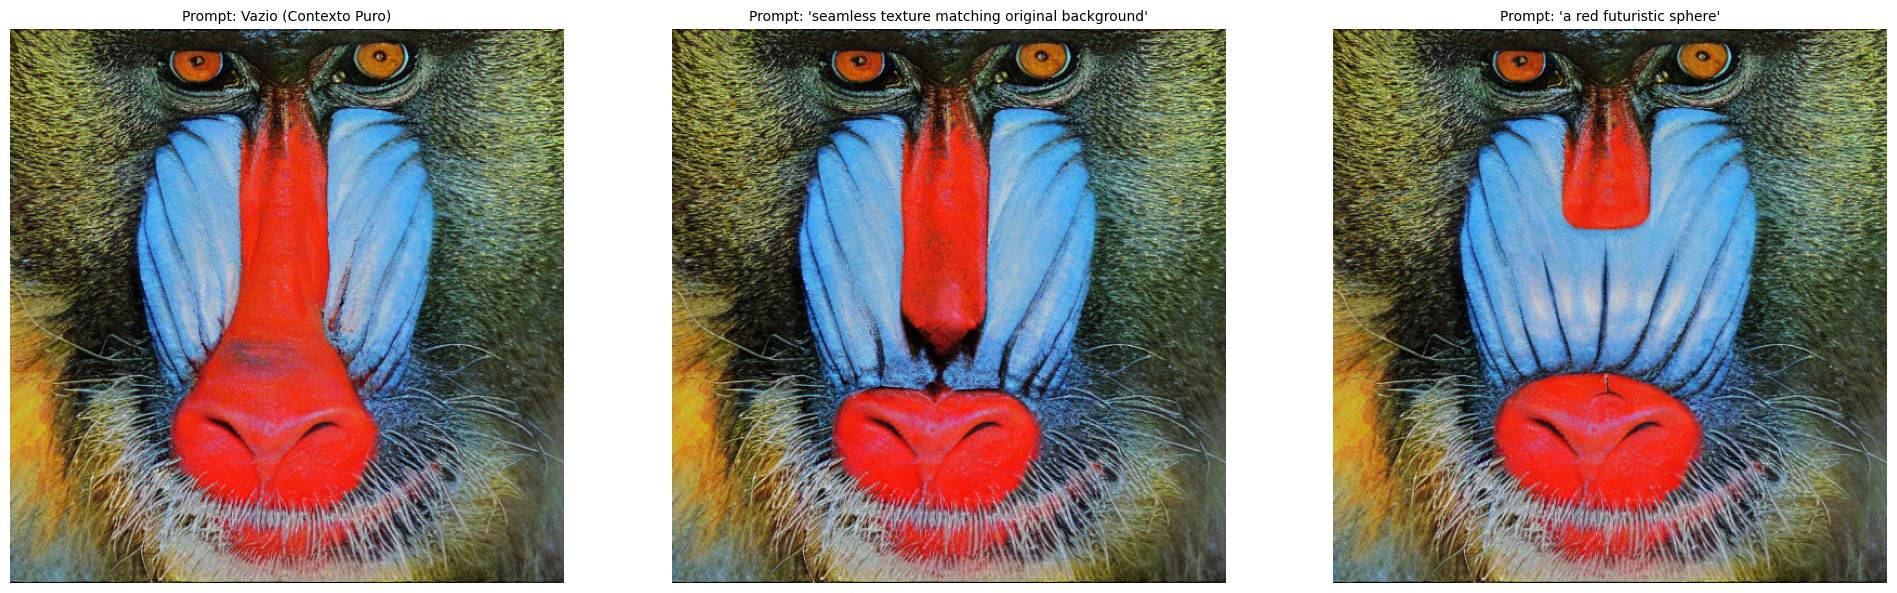

In [16]:
prompts_to_test = [
    "", # Prompt Vazio (Baseline - o modelo deve inferir apenas pelo contexto)
    "seamless texture matching original background", # Foco em consistência
    "a red futuristic sphere", # Inserção de objeto novo (modificação semântica)
]

print(f"Executando teste com {len(prompts_to_test)} variações de prompt...\n")

fig, axes = plt.subplots(1, len(prompts_to_test), figsize=(20, 6))

for idx, test_prompt in enumerate(prompts_to_test):
    print(f"Testando prompt: '{test_prompt}'")
    
    with torch.no_grad():
        res = pipe(
            prompt=test_prompt,
            image=source_image,
            mask_image=mask_image,
            num_inference_steps=30,
            guidance_scale=7.5
        ).images[0]
    
    # Salvar
    safe_name = "empty" if test_prompt == "" else test_prompt.split()[0]
    res.save(OUTPUT_DIR / f"{img_name}_prompt_{safe_name}.png")
    
    # Visualizar
    axes[idx].imshow(res)
    title = f"Prompt: '{test_prompt}'" if test_prompt else "Prompt: Vazio (Contexto Puro)"
    axes[idx].set_title(title, fontsize=10)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()


## 8. Experimento: Tamanho da Máscara
Avaliação da robustez do modelo ao tentar reconstruir áreas progressivamente maiores (20%, 35% e 50% da imagem).

Executando teste com 3 tamanhos de máscara...

Testando máscara: 20%


100%|██████████| 30/30 [00:04<00:00,  6.95it/s]


Testando máscara: 35%


100%|██████████| 30/30 [00:04<00:00,  6.97it/s]


Testando máscara: 50%


100%|██████████| 30/30 [00:04<00:00,  7.38it/s]


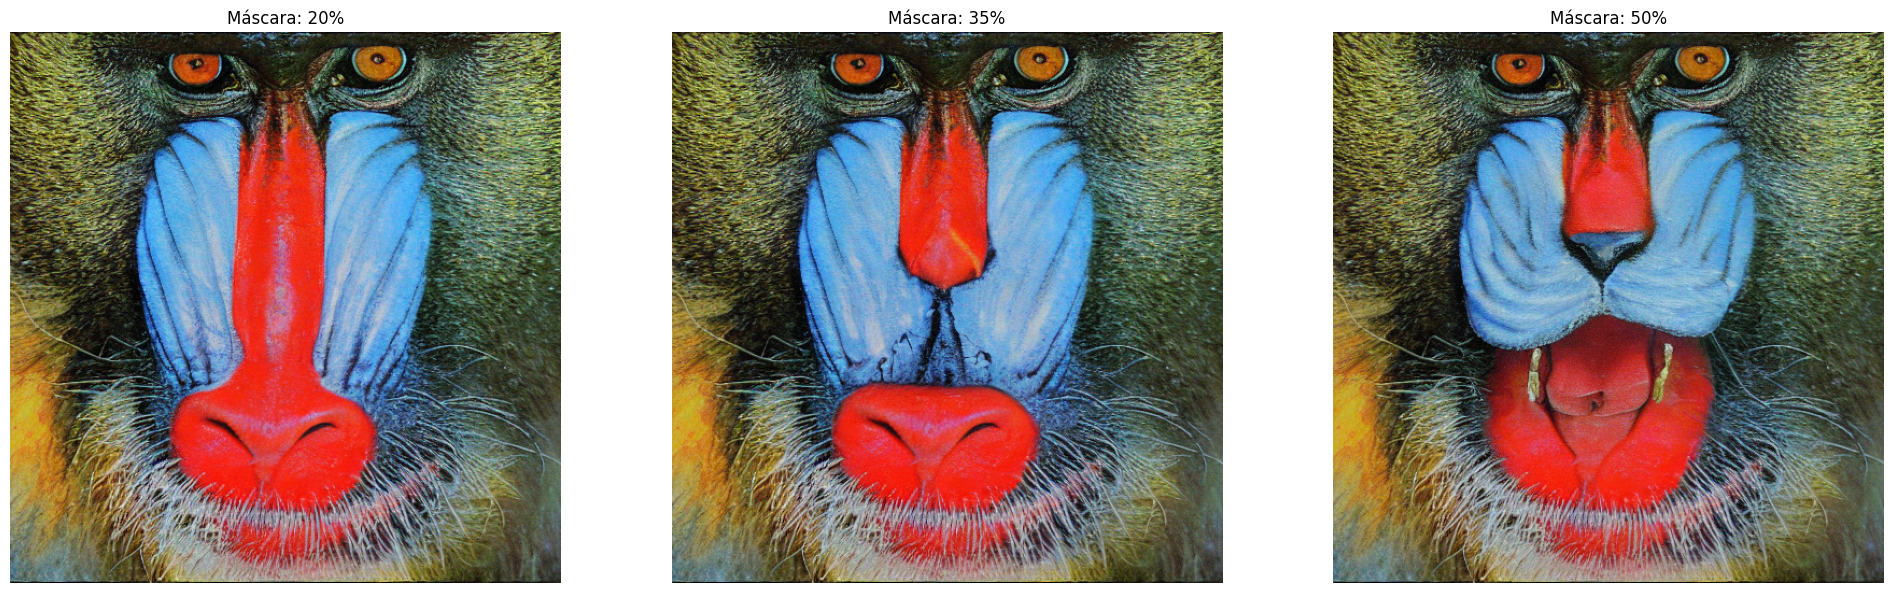

In [17]:
mask_ratios = [0.20, 0.35, 0.50]
print(f"Executando teste com {len(mask_ratios)} tamanhos de máscara...\n")

fig, axes = plt.subplots(1, len(mask_ratios), figsize=(20, 6))

for idx, ratio in enumerate(mask_ratios):
    print(f"Testando máscara: {int(ratio*100)}%")
    
    # Gerar nova máscara
    temp_mask, _ = create_mask(source_image, ratio=ratio)
    
    with torch.no_grad():
        res = pipe(
            prompt="high quality, detailed",
            image=source_image,
            mask_image=temp_mask,
            num_inference_steps=30,
            guidance_scale=7.5
        ).images[0]
        
    # Salvar
    res.save(OUTPUT_DIR / f"{img_name}_mask_{int(ratio*100)}.png")
    
    # Visualizar
    axes[idx].imshow(res)
    axes[idx].set_title(f"Máscara: {int(ratio*100)}%", fontsize=12)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()
